### Miniproject 2 - parallel mandelbrot


#### Mileston 1 - refactor code

Median: 0.0511s (min=0.0510, max=0.0512)


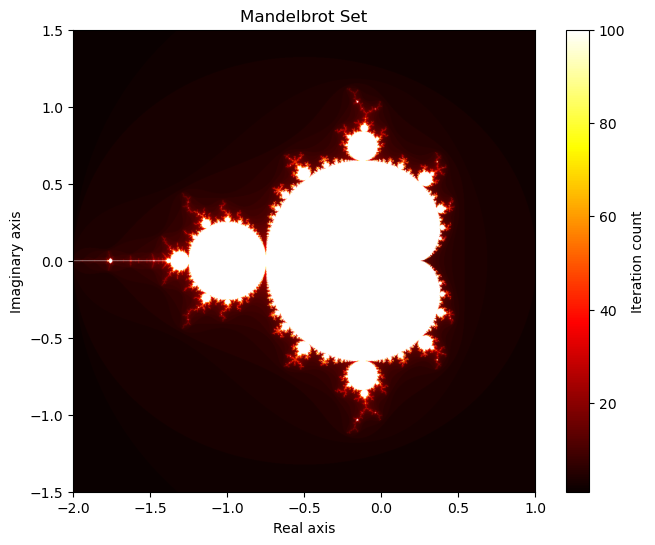

In [ ]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
import time
import statistics


@njit
def mandelbrot_pixel(c_real, c_imag, max_iter):
    z_real = 0.0
    z_imag = 0.0

    for j in range(max_iter):
        if z_real*z_real + z_imag*z_imag > 4.0:
            return j

        new_real = z_real*z_real - z_imag*z_imag + c_real
        new_imag = 2.0 * z_real * z_imag + c_imag

        z_real = new_real
        z_imag = new_imag

    return max_iter


@njit
def mandelbrot_chunk(row_start, row_end, N,
                     x_min, x_max, y_min, y_max, max_iter):

    height = row_end - row_start
    out = np.empty((height, N), dtype=np.int32)

    dx = (x_max - x_min) / N
    dy = (y_max - y_min) / N

    for r in range(height):
        c_imag = y_min + (r + row_start) * dy
        c_real = x_min

        for col in range(N):
            out[r, col] = mandelbrot_pixel(c_real, c_imag, max_iter)
            c_real += dx  

    return out

def mandelbrot_serial(N, x_min, x_max, y_min, y_max, max_iter):
    return mandelbrot_chunk(
        row_start=0,
        row_end=N,
        N=N,
        x_min=x_min,
        x_max=x_max,
        y_min=y_min,
        y_max=y_max,
        max_iter=max_iter
    )

#####Visualization still made with AI as it is reused from mp1 #####
##### Visualization function #####
def visualize_mandelbrot(grid, title="Mandelbrot Set", cmap="hot", filename="mandelbrot.png"):
    plt.figure(figsize=(8, 6))

    plt.imshow(grid, extent=[-2, 1, -1.5, 1.5],
                   origin='lower', cmap=cmap)

    plt.colorbar(label="Iteration count")
    plt.title(title)
    plt.xlabel("Real axis")
    plt.ylabel("Imaginary axis")

    plt.savefig(filename)
    plt.show()


def benchmark(func, *args, n_runs=3):
    """Time func, return median runtime and result."""
    times = []

    for _ in range(n_runs):
        t0 = time.perf_counter()
        result = func(*args)
        times.append(time.perf_counter() - t0)

    median_t = statistics.median(times)
    print(
        f"Median: {median_t:.4f}s "
        f"(min={min(times):.4f}, max={max(times):.4f})"
    )

    return median_t, result

if __name__ == "__main__":

    mandelbrot_serial(1024, -2, 1, -1.5, 1.5, 100)
    
    median_time, result = benchmark(
        mandelbrot_serial,
        1024, -2, 1, -1.5, 1.5, 100
    )

    visualize_mandelbrot(result)
    

### Mileston 2 --- Parallel Implementation

In [ ]:
from multiprocessing import Pool

def worker(args):
    return mandelbrot_chunk(*args)



def mandelbrot_parallel(N, x_min, x_max, y_min, y_max, max_iter, n_workers):

    # splitting rows among workers
    chunk_size = max(1,N // n_workers)

    #initializ list
    chunks,row = [],0

    # divides the image rows into chunks
    while row < N:
        row_end = min(row + chunk_size, N)

        chunks.append((
            row, row_end, N,
            x_min, x_max, y_min, y_max, max_iter
        ))
        
        row = row_end

    # sends each chunk to a separate process
    with Pool(n_workers) as pool:
        parts = pool.map(worker, chunks)

    return np.vstack(parts)